# Analisis De Resultados de Entrenamiento

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

### Análisis del Rendimiento por Episodio (`train_monitor.csv`)
Este archivo es generado automáticamente por el *Monitor* de *stable_baselines3*. Contiene el registro crudo y sin procesar de cada intento (episodio) que el agente ha realizado en el entorno durante su entrenamiento. 

Las variables que registra son:
* **`r` (Recompensa / Reward):** La puntuación total obtenida por el robot al finalizar el episodio. Valores negativos indican caídas o fracasos, mientras que valores cercanos a 300 indican que ha completado el recorrido con éxito.
* **`l` (Longitud / Length):** El número de *timesteps* (pasos de simulación) que el robot logró mantenerse activo en ese episodio antes de caerse o llegar a la meta.
* **`t` (Tiempo / Time):** El tiempo transcurrido en segundos desde el inicio del entrenamiento hasta que finalizó ese episodio.

In [11]:
df_monitor = pd.read_csv('train_monitor.csv', skiprows=1)
print("--- ANÁLISIS PRELIMINAR: train_monitor.csv ---")
print(f"Número total de episodios entrenados: {len(df_monitor)}")
print("\nPrimeras 5 filas:")
display(df_monitor.head())

print("\nEstadísticas descriptivas de las recompensas y duraciones:")
display(df_monitor.describe())

--- ANÁLISIS PRELIMINAR: train_monitor.csv ---
Número total de episodios entrenados: 591

Primeras 5 filas:


,r,l,t
0,-100.110205,82,1.304485
1,-192.820161,1487,23.185199
2,-107.458590,55,23.907784
3,-102.007003,61,24.718464
4,-101.269283,62,25.554568



Estadísticas descriptivas de las recompensas y duraciones:


,r,l,t
count,591.000000,591.000000,591.000000
mean,165.780188,845.350254,4227.008715
std,185.153399,411.782052,2777.521805
min,-219.492656,39.000000,1.304485
25%,-73.826469,828.500000,1585.808973
50%,294.715081,889.000000,4347.972428
75%,307.497726,981.000000,6672.410711
max,317.207894,1600.000000,8848.835357


In [30]:
df_monitor['episode'] = df_monitor.index # Columna con el número de episodio

# Convertimos el tiempo (t) de segundos a HORAS
df_monitor['t_hours'] = df_monitor['t'] / 3600  

# Configurar el estilo visual general
sns.set_theme(style="whitegrid")

# ==========================================
# GRÁFICO 1: RECOMPENSA VS TIEMPO (HORAS)
# ==========================================
plt.figure(figsize=(9, 5))

# Scatter de datos reales
sns.scatterplot(
    data=df_monitor,
    x='t_hours',          
    y='r',
    hue='l',              
    palette='viridis',
    alpha=0.6,
    edgecolor=None
)

# Añadir la media móvil (con tu configuración personalizada)
df_monitor['reward_smooth'] = df_monitor['r'].rolling(window=4).median().rolling(window=10).mean()
sns.lineplot(
    data=df_monitor, 
    x='t_hours', 
    y='reward_smooth', 
    color='red', 
    linewidth=2.5, 
    label='Tendencia (Mediana 4 + Media 10)'
)

plt.title('Evolución de la Recompensa a lo largo del Tiempo', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo de Entrenamiento Transcurrido (Horas)', fontsize=12)
plt.ylabel('Recompensa Total', fontsize=12)
plt.legend(title='Duración (Pasos)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('grafico_recompensa_tiempo.pdf', format='pdf', bbox_inches='tight')
plt.close() # Cierra la figura


# ==========================================
# GRÁFICO 2: TIEMPO ACUMULADO VS EPISODIO (Intercepto = 0)
# ==========================================
plt.figure(figsize=(9, 5))

x = df_monitor['episode'].values
y = df_monitor['t_hours'].values

# Calcular la regresión lineal forzando intercepto a 0 (y = m*x)
# Fórmula: m = sum(x*y) / sum(x^2)
m = np.sum(x * y) / np.sum(x**2)

# 1. Dibujar los puntos experimentales reales
sns.scatterplot(
    x=x,
    y=y,
    color='purple',
    alpha=0.4,       
    s=5,            
    edgecolor=None,
    label='Tiempos Experimentales'
)

# 2. Dibujar la línea de regresión (y = m*x)
y_pred = m * x
plt.plot(
    x, 
    y_pred, 
    color='red', 
    linewidth=2.5, 
    linestyle='--',  
    label=f'Ajuste Lineal ($y = {m:.5f}x$)'
)

plt.title('Coste Computacional: Tiempo vs Número de Episodios', fontsize=14, fontweight='bold')
plt.xlabel('Número de Episodio', fontsize=12)
plt.ylabel('Tiempo Acumulado (Horas)', fontsize=12)
plt.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('grafico_tiempo_episodio.pdf', format='pdf', bbox_inches='tight')
plt.close()

print("¡Ambas figuras PDF han sido generadas y exportadas con éxito!")

¡Ambas figuras PDF han sido generadas y exportadas con éxito!


### Análisis de las Métricas de Entrenamiento (`progress.csv`)
Este archivo contiene las métricas internas del algoritmo *Soft Actor Critic (SAC)* agregadas a lo largo del tiempo. A diferencia del monitor, que guarda cada episodio, este archivo guarda promedios y datos de las redes neuronales cada cierto número de pasos.

Las variables más relevantes para nuestro análisis son:
* **`time/total_timesteps`:** El número total de interacciones del agente con el entorno. Será nuestro eje horizontal (eje X) para evaluar la evolución temporal.
* **`eval/mean_reward`:** La recompensa media obtenida durante las fases de evaluación pura (sin exploración aleatoria). Es el indicador más fiable de cuánto ha aprendido el modelo.
* **`train/actor_loss` y `train/critic_loss`:** Los valores de pérdida (*loss*) de las redes neuronales que componen la arquitectura de SAC, útiles para diagnosticar la estabilidad del aprendizaje matemático.

In [2]:

df_progress = pd.read_csv('progress.csv')

print("\n\n--- ANÁLISIS PRELIMINAR: progress.csv ---")
print(f"Número de registros de métricas: {len(df_progress)}")
print("\nColumnas disponibles en el progreso:")
print(list(df_progress.columns))

print("\nPrimeras 5 filas (métricas clave):")
# Filtramos solo algunas columnas clave para que la tabla sea fácil de leer
columnas_clave = ['time/total_timesteps', 'eval/mean_reward', 'rollout/ep_rew_mean', 'train/actor_loss']
# Usamos dropna() en la vista para no ver filas vacías de evaluación
display(df_progress[columnas_clave].dropna(subset=['eval/mean_reward']).head())

print("\nEvolución final del entrenamiento (últimos 5 registros):")
display(df_progress[columnas_clave].dropna(subset=['eval/mean_reward']).tail())



--- ANÁLISIS PRELIMINAR: progress.csv ---
Número de registros de métricas: 647

Columnas disponibles en el progreso:
['time/total_timesteps', 'eval/mean_reward', 'train/n_updates', 'train/ent_coef_loss', 'train/learning_rate', 'train/actor_loss', 'eval/mean_ep_length', 'train/ent_coef', 'train/critic_loss', 'rollout/ep_len_mean', 'time/fps', 'time/episodes', 'rollout/ep_rew_mean', 'time/time_elapsed']

Primeras 5 filas (métricas clave):


,time/total_timesteps,eval/mean_reward,rollout/ep_rew_mean,train/actor_loss
0,1000,-81.141420,NaN,-71.532326
3,2000,-98.053811,NaN,-123.097313
6,3000,-117.499035,NaN,-134.784653
8,4000,-42.449512,NaN,-153.506927
9,5000,-69.351653,NaN,-166.374802



Evolución final del entrenamiento (últimos 5 registros):


,time/total_timesteps,eval/mean_reward,rollout/ep_rew_mean,train/actor_loss
641,496000,282.558438,NaN,-56.962223
642,497000,318.166772,NaN,-57.059776
644,498000,316.801320,NaN,-56.506817
645,499000,312.746324,NaN,-56.901558
646,500000,317.079953,NaN,-56.389481


In [29]:
# 2. Configurar el estilo visual general
sns.set_theme(style="darkgrid")

# ==========================================
# GRÁFICO 1: Curva de Aprendizaje (Recompensas)
# ==========================================
plt.figure(figsize=(8, 5))
eval_data = df_progress.dropna(subset=['eval/mean_reward'])
train_data = df_progress.dropna(subset=['rollout/ep_rew_mean'])

sns.lineplot(data=eval_data, x='time/total_timesteps', y='eval/mean_reward', 
             label='Evaluación (Agente determinista)', color='blue', linewidth=2.5)
sns.lineplot(data=train_data, x='time/total_timesteps', y='rollout/ep_rew_mean', 
             label='Entrenamiento (Media)', color='orange', alpha=0.6)

plt.axhline(y=300, color='green', linestyle='--', linewidth=2, label='Meta Resuelta (300 ptos)')
plt.title('Rendimiento del Agente: Evolución de la Recompensa', fontsize=14, fontweight='bold')
plt.xlabel('Pasos de Simulación Totales (Timesteps)', fontsize=12)
plt.ylabel('Recompensa Media', fontsize=12)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('grafico_recompensas.pdf', format='pdf', bbox_inches='tight') # <-- Guarda como PDF vectorial
plt.close() # Cierra la figura para no sobreescribirla en la siguiente


# ==========================================
# GRÁFICO 2: Supervivencia (Longitud del Episodio)
# ==========================================
plt.figure(figsize=(8, 5))
eval_len = df_progress.dropna(subset=['eval/mean_ep_length'])
train_len = df_progress.dropna(subset=['rollout/ep_len_mean'])

sns.lineplot(data=eval_len, x='time/total_timesteps', y='eval/mean_ep_length', 
             label='Evaluación', color='darkgreen', linewidth=2)
sns.lineplot(data=train_len, x='time/total_timesteps', y='rollout/ep_len_mean', 
             label='Entrenamiento', color='lightgreen', alpha=0.7)

plt.title('Supervivencia: Longitud Promedio de los Episodios', fontsize=14, fontweight='bold')
plt.xlabel('Pasos de Simulación Totales (Timesteps)', fontsize=12)
plt.ylabel('Pasos por Episodio', fontsize=12)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('grafico_supervivencia.pdf', format='pdf', bbox_inches='tight')
plt.close()


# ==========================================
# GRÁFICO 3: Convergencia del Crítico (Escala Log)
# ==========================================
plt.figure(figsize=(8, 5))
critic_data = df_progress.dropna(subset=['train/critic_loss'])

sns.lineplot(data=critic_data, x='time/total_timesteps', y='train/critic_loss', 
             color='red', label='Critic Loss')
plt.yscale('log')
plt.title('Pérdida del Crítico (Critic Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Pasos de Simulación Totales (Timesteps)', fontsize=12)
plt.ylabel('Loss (Escala Logarítmica)', fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('grafico_critic_loss.pdf', format='pdf', bbox_inches='tight')
plt.close()


# ==========================================
# GRÁFICO 4: Convergencia del Actor (Escala Lineal)
# ==========================================
plt.figure(figsize=(8, 5))
actor_data = df_progress.dropna(subset=['train/actor_loss'])

sns.lineplot(data=actor_data, x='time/total_timesteps', y='train/actor_loss', 
             color='purple', label='Actor Loss', alpha=0.9)
plt.title('Pérdida del Actor (Actor Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Pasos de Simulación Totales (Timesteps)', fontsize=12)
plt.ylabel('Loss (Escala Lineal)', fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('grafico_actor_loss.pdf', format='pdf', bbox_inches='tight')
plt.close()

print("¡Las 4 figuras PDF han sido generadas y guardadas con éxito!")

¡Las 4 figuras PDF han sido generadas y guardadas con éxito!


### Análisis de Optimización de Hiperparámetros (Finetuning)
En esta fase, evaluamos múltiples configuraciones del algoritmo *Soft Actor Critic (SAC)*. Cada experimento (trial) se ha guardado en una subcarpeta independiente dentro del directorio `/finetuning`, conteniendo dos archivos vitales:
1. `hyperparameters.txt`: Define la arquitectura y parámetros matemáticos (como la tasa de aprendizaje, el factor de descuento $\gamma$, etc.) usados en ese experimento.
2. `progress.csv`: Contiene las métricas de aprendizaje de ese agente en particular.

El siguiente bloque de código recorre automáticamente todas las subcarpetas, extrae los parámetros de configuración y une todas las curvas de aprendizaje en un único *DataFrame* para permitir su comparación directa. Además, genera una tabla resumen con el mejor rendimiento de cada modelo.

In [39]:
base_dir = "finetuning"
lista_progresos = []
resumen_experimentos = []

# Iteramos por cada subcarpeta
if os.path.exists(base_dir):
    for folder_name in os.listdir(base_dir):
        folder_path = os.path.join(base_dir, folder_name)
        if not os.path.isdir(folder_path):
            continue
            
        hp_file = os.path.join(folder_path, "hyperparameters.txt")
        prog_file = os.path.join(folder_path, "progress.csv")
        
        # 1. Leer los hiperparámetros
        hp_dict = {"Experimento": folder_name}
        if os.path.exists(hp_file):
            with open(hp_file, 'r') as f:
                for line in f:
                    if ":" in line:
                        key, val = line.strip().split(":", 1)
                        try:
                            hp_dict[key.strip()] = float(val.strip())
                        except ValueError:
                            hp_dict[key.strip()] = val.strip()

        # 2. Leer el progreso para sacar la recompensa máxima
        if os.path.exists(prog_file):
            df_prog = pd.read_csv(prog_file)
            df_prog['Experimento'] = folder_name
            lista_progresos.append(df_prog)
            
            if 'eval/mean_reward' in df_prog.columns:
                hp_dict['Recompensa_Máxima'] = df_prog['eval/mean_reward'].max()
            elif 'rollout/ep_rew_mean' in df_prog.columns:
                hp_dict['Recompensa_Máxima'] = df_prog['rollout/ep_rew_mean'].max()
            else:
                hp_dict['Recompensa_Máxima'] = 0
                
        resumen_experimentos.append(hp_dict)

# Consolidamos todos los datos
df_all_progress = pd.concat(lista_progresos, ignore_index=True)
df_summary = pd.DataFrame(resumen_experimentos)

# LIMPIEZA PARA LAS GRÁFICAS: Convertir a categóricas las variables discretas
columnas_categoricas = ['batch_size', 'net_arch_width', 'gamma']
for col in columnas_categoricas:
    if col in df_summary.columns:
        # Convertimos a string primero para que Seaborn lo trate como categorías discretas, no continuas
        df_summary[col] = df_summary[col].astype(int).astype(str) if col != 'gamma' else df_summary[col].astype(str)

df_summary = df_summary.sort_values(by='Recompensa_Máxima', ascending=False).reset_index(drop=True)

print(f"Total de experimentos cargados: {len(df_summary)}")
display(df_summary.head()) # Mostramos solo el Top 5

Total de experimentos cargados: 100


,Experimento,learning_rate,batch_size,net_arch_width,tau,gamma,Recompensa_Máxima
0,datatraining_trial_18,0.000197,512,256,0.038853,0.995,94.030478
1,datatraining_trial_76,0.000016,128,256,0.002529,0.98,-6.295753
2,datatraining_trial_61,0.000012,512,256,0.002625,0.99,-7.164429
3,datatraining_trial_84,0.000020,256,400,0.001340,0.995,-7.497377
4,datatraining_trial_12,0.000010,512,400,0.001993,0.995,-11.661356


### Visualización Comparativa de los Modelos
Para determinar cuál es la mejor configuración, no basta con mirar la recompensa máxima absoluta. Es crucial analizar la **estabilidad** y la **velocidad de convergencia**. 

A continuación, se generan dos visualizaciones clave:
1. **Curvas de Aprendizaje Superpuestas:** Permite observar qué experimento aprende más rápido y cuál mantiene un rendimiento estable sin sufrir colapsos catastróficos.
2. **Impacto de la Tasa de Aprendizaje (Learning Rate):** Un análisis específico de cómo el *learning rate* (uno de los hiperparámetros más sensibles en Reinforcement Learning) afecta a la recompensa final obtenida.

In [42]:
sns.set_theme(style="whitegrid")

# ==========================================
# GRÁFICO 1: SCATTER MULTIDIMENSIONAL (Los 99 modelos)
# ==========================================
plt.figure(figsize=(10, 6))

# Eje X = learning rate (log)
# Eje Y = Recompensa
# Color = batch_size
# Forma del marcador = net_arch_width
sns.scatterplot(
    data=df_summary,
    x='learning_rate',
    y='Recompensa_Máxima',
    hue='batch_size',
    style='net_arch_width',
    palette='Set1',
    s=120, # Tamaño grande para que se vean bien las formas
    alpha=0.8
)

plt.xscale('log')
plt.title('Impacto de Hiperparámetros: Learning Rate, Batch Size y Arquitectura', fontsize=14, fontweight='bold')
plt.xlabel('Learning Rate (Escala Logarítmica)', fontsize=12)
plt.ylabel('Recompensa Máxima Alcanzada', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('optuna_scatter_multidimensional.pdf', format='pdf', bbox_inches='tight')
plt.close()


# ==========================================
# GRÁFICO 2: RENDIMIENTO POR ARQUITECTURA (Boxplot)
# ==========================================
# Una gráfica de caja es ideal para comparar qué tamaño de red (net_arch_width) rinde mejor en general
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_summary,
    x='net_arch_width',
    y='Recompensa_Máxima',
    palette='pastel'
)
sns.stripplot(
    data=df_summary,
    x='net_arch_width',
    y='Recompensa_Máxima',
    color='black',
    alpha=0.4,
    size=5
) # Añadimos los puntos reales sobre la caja

plt.title('Distribución de Recompensas según Ancho de la Red (Net Arch Width)', fontsize=14, fontweight='bold')
plt.xlabel('Neuronas por Capa (net_arch_width)', fontsize=12)
plt.ylabel('Recompensa Máxima', fontsize=12)

plt.tight_layout()
plt.savefig('optuna_boxplot_arquitectura.pdf', format='pdf', bbox_inches='tight')
plt.close()


# ==========================================
# GRÁFICO 3: CURVAS DE APRENDIZAJE (SOLO EL TOP 5)
# ==========================================
plt.figure(figsize=(10, 6))

# Extraemos los nombres de los 5 mejores experimentos
top_5_experimentos = df_summary['Experimento'].head(5).tolist()

# Filtramos el dataframe de progresos para quedarnos solo con el Top 5
df_top5_progress = df_all_progress[df_all_progress['Experimento'].isin(top_5_experimentos)]

sns.lineplot(
    data=df_top5_progress.dropna(subset=['rollout/ep_rew_mean']),
    x='time/total_timesteps',
    y='rollout/ep_rew_mean',
    hue='Experimento', 
    linewidth=2.5,
    palette='tab10'
)

plt.title('Curvas de Convergencia: Top 5 Mejores Modelos', fontsize=14, fontweight='bold')
plt.xlabel('Pasos de Simulación Totales (Timesteps)', fontsize=12)
plt.ylabel('Recompensa Media (Entrenamiento)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Top 5 Modelos')

plt.tight_layout()
plt.savefig('optuna_curvas_top5.pdf', format='pdf', bbox_inches='tight')
plt.close()

print("¡Las gráficas multidimensionales y del Top 5 han sido exportadas a PDF exitosamente!")

C:\Users\bogur\AppData\Local\Temp\ipykernel_22460\402625064.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


¡Las gráficas multidimensionales y del Top 5 han sido exportadas a PDF exitosamente!


### Análisis de Sensibilidad: Tau ($\tau$) y Gamma ($\gamma$)
Para completar el estudio de hiperparámetros, analizamos otros dos factores críticos en el algoritmo SAC:
1. **Factor de suavizado ($\tau$):** Controla la velocidad de actualización de las redes "target". Valores muy pequeños hacen el aprendizaje más estable pero lento, mientras que valores altos pueden desestabilizar la convergencia.
2. **Factor de descuento ($\gamma$):** Determina la importancia que el agente otorga a las recompensas futuras frente a las inmediatas. En entornos de locomoción como *BipedalWalker*, un $\gamma$ alto es fundamental para que el robot planifique pasos a largo plazo.

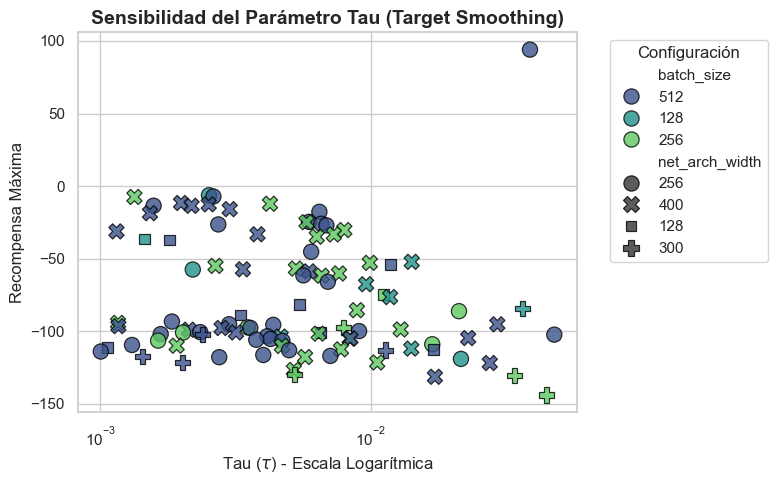

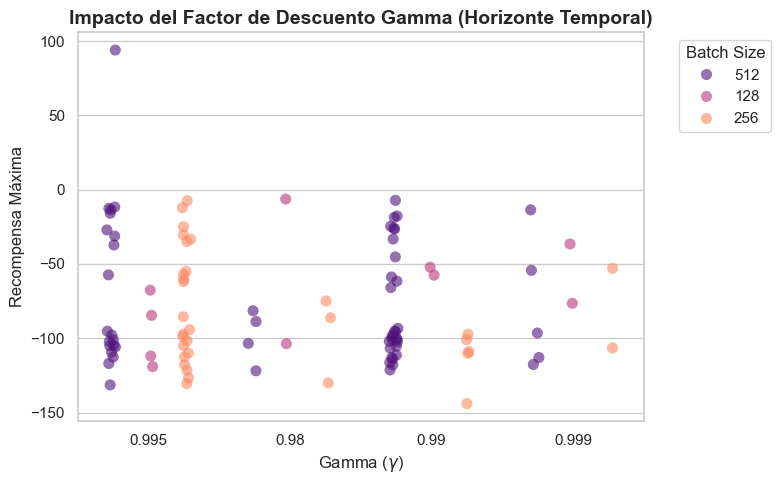

¡Análisis de Tau y Gamma exportados a PDF correctamente!


In [44]:
# ==========================================
# GRÁFICO 4: TAU vs RECOMPENSA MÁXIMA
# ==========================================
if 'tau' in df_summary.columns:
    plt.figure(figsize=(8, 5))
    
    sns.scatterplot(
        data=df_summary,
        x='tau',
        y='Recompensa_Máxima',
        hue='batch_size', # Podemos cruzarlo con batch_size para ver si hay relación
        style='net_arch_width',
        s=120,
        palette='viridis',
        alpha=0.8,
        edgecolor='black'
    )
    
    # Tau suele explorarse en escala logarítmica
    plt.xscale('log')     
    plt.title('Sensibilidad del Parámetro Tau (Target Smoothing)', fontsize=14, fontweight='bold')
    plt.xlabel('Tau ($\\tau$) - Escala Logarítmica', fontsize=12)
    plt.ylabel('Recompensa Máxima', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Configuración')
    
    plt.tight_layout()
    plt.savefig('optuna_tau_analysis.pdf', format='pdf', bbox_inches='tight')
    plt.show()


# ==========================================
# GRÁFICO 5: GAMMA vs RECOMPENSA MÁXIMA
# ==========================================
if 'gamma' in df_summary.columns:
    plt.figure(figsize=(8, 5))
    
    # Dado que gamma tiene pocos valores específicos (0.98, 0.99, etc.), 
    # un scatter plot con un poco de "jitter" (desplazamiento) ayuda a ver la densidad.
    sns.stripplot(
        data=df_summary,
        x='gamma',
        y='Recompensa_Máxima',
        hue='batch_size',
        dodge=True,
        alpha=0.6,
        size=8,
        palette='magma'
    )
        
    plt.title('Impacto del Factor de Descuento Gamma (Horizonte Temporal)', fontsize=14, fontweight='bold')
    plt.xlabel('Gamma ($\\gamma$)', fontsize=12)
    plt.ylabel('Recompensa Máxima', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Batch Size')
    
    plt.tight_layout()
    plt.savefig('optuna_gamma_analysis.pdf', format='pdf', bbox_inches='tight')
    plt.show()

print("¡Análisis de Tau y Gamma exportados a PDF correctamente!")